In [153]:
import numpy as np
import igor2.binarywave as bw
import pandas as pd
import os
import re
import shutil
import yaml
import matplotlib.pyplot as plt
import glob
from scipy.stats import linregress

In [82]:
# Load the Igor binary wave file
dir  = '/Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_1/raw/'
proc_dir = os.path.join(dir, 'processed_temp')
yaml_file = '/Volumes/DL_Share2/Boris/Projects/AFM Pressure [P]/Applying pressure/AP_1/AP_1_runs.yaml'

Sorting and renaming files

In [83]:

sorting = False


# Load yaml
with open(yaml_file, 'r') as f:
    config = yaml.safe_load(f)

def get_run(filename):
    if '_FD2_' in filename:
        return 'run_FD2'
    elif '_FD_' in filename:
        return 'run_FD'
    return None

# Create output folder
out_dir = os.path.join(dir, 'processed_temp')
os.makedirs(out_dir, exist_ok=True)

# Get all ibw files
all_files = [f for f in os.listdir(dir) if f.endswith('.ibw')]

if sorting:
    for filename in all_files:
        run = get_run(filename)
        if run is None:
            continue

        # Extract force value and version from filename
        # matches things like 900nN, 10uN, 1uN etc.
        force_match = re.search(r'(\d+(?:\.\d+)?(?:nN|uN))', filename, re.IGNORECASE)
        version_match = re.search(r'(\d{4})\.ibw$', filename)

        if not force_match or not version_match:
            print(f"Skipping {filename} - could not parse force or version")
            continue

        force = force_match.group(1)
        version = version_match.group(1)

        # Check force is in the yaml for this run
        valid_forces = config[run]['acquisitions']['Force']
        if force not in valid_forces:
            print(f"Skipping {filename} - force {force} not in {run} yaml")
            continue

        new_name = f"{run}_{force}_{version}.ibw"
        src = os.path.join(dir, filename)
        dst = os.path.join(out_dir, new_name)

        shutil.copy2(src, dst)
        print(f"{filename} -> {new_name}")

In [165]:
filename = 'run_FD_100nN_0009.ibw'
filename_force = filename.split('_')[2]
wave_file = os.path.join(proc_dir, filename)
# Load the .ibw file
data = bw.load(wave_file)

# Access the wave data (numpy array)
wave = data['wave']
wave_data = wave['wData']

labels = [l.decode() for l in data['wave']['labels'][1] if l]
df = pd.DataFrame(wave_data, columns=labels)
print(df.head())   

        Raw          Defl     ZSnsr
0  0.000004  1.012808e-08  0.000004
1  0.000004  1.012884e-08  0.000004
2  0.000004  1.012865e-08  0.000004
3  0.000004  1.012837e-08  0.000004
4  0.000004  1.012646e-08  0.000004


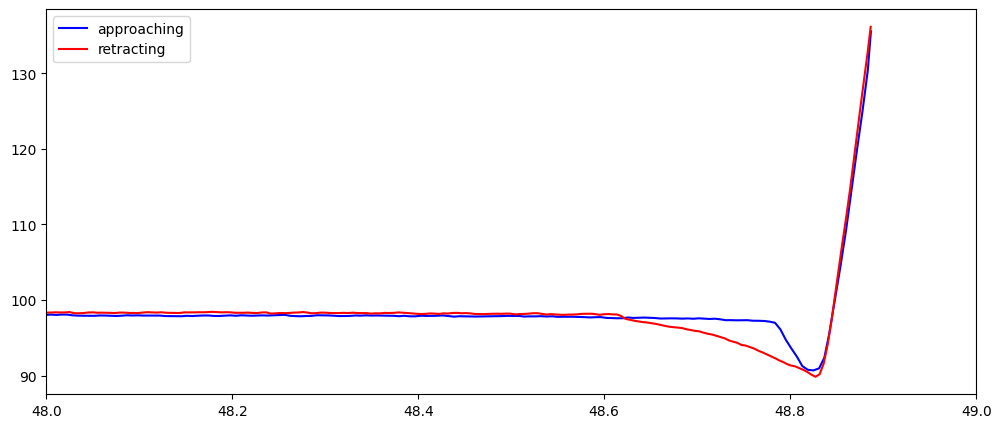

In [108]:
def get_curve_indices(filename):
    data = bw.load(os.path.join(proc_dir, filename))
    wave = data['wave']
    labels = [l.decode() for l in wave['labels'][1] if l]
    df = pd.DataFrame(wave['wData'], columns=labels)
    
    smallest = df['Defl'].nsmallest(2).index.tolist()
    largest = df['Defl'].nlargest(1).index.tolist()
    
    return smallest, largest

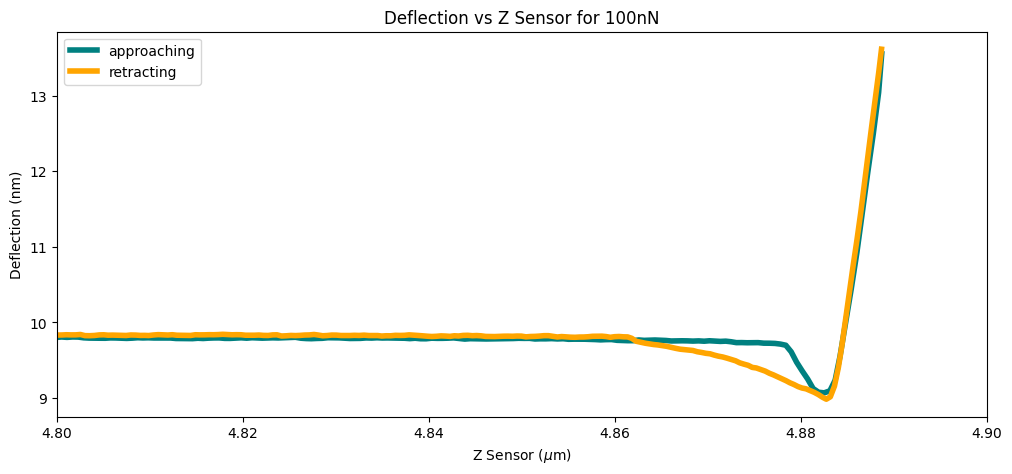

In [201]:

filename = 'run_FD_100nN_0009.ibw'
filename_force = filename.split('_')[2]
fig, ax = plt.subplots(figsize=(12, 5))

smallest, largest = get_curve_indices(filename)
split = largest[0]
x1 = df['ZSnsr'].iloc[:split]*1e6
y1 = df['Defl'].iloc[:split]*1e9
x2 = df['ZSnsr'].iloc[split:]*1e6
y2 = df['Defl'].iloc[split:]*1e9
ax.plot(x1, y1, color='teal', linewidth=4)
ax.plot(x2, y2, color='orange', linewidth=4)

ax.legend(handles=[
    plt.Line2D([0], [0], color='teal', label='approaching', linewidth=4),
    plt.Line2D([0], [0], color='orange',  label='retracting', linewidth=4),
])

ax.set_xlabel(r'Z Sensor ($\mu$m)')
ax.set_ylabel(r'Deflection (nm)')
ax.set_title(f'Deflection vs Z Sensor for {filename_force}')

ax.set_xlim(4.8, 4.9)
plt.show()

In [134]:
def get_average_indices(run, acquisition, proc_dir):
    pattern = os.path.join(glob.escape(proc_dir), f"{run}_{acquisition}_*.ibw")
    files = glob.glob(pattern)
    
    if not files:
        print(f"No files found for {run} {acquisition}")
        return None

    all_smallest1_defl, all_smallest2_defl, all_largest_defl = [], [], []
    all_smallest1_z,    all_smallest2_z,    all_largest_z    = [], [], []

    for filename in files:
        data = bw.load(filename)
        wave = data['wave']
        labels = [l.decode() for l in wave['labels'][1] if l]
        df = pd.DataFrame(wave['wData'], columns=labels)

        smallest, largest = get_curve_indices(filename)

        all_smallest1_defl.append(df['Defl'].iloc[smallest[0]])
        all_smallest2_defl.append(df['Defl'].iloc[smallest[1]])
        all_largest_defl.append(df['Defl'].iloc[largest[0]])

        all_smallest1_z.append(df['ZSnsr'].iloc[smallest[0]])
        all_smallest2_z.append(df['ZSnsr'].iloc[smallest[1]])
        all_largest_z.append(df['ZSnsr'].iloc[largest[0]])

    avg_mins_defl = np.mean([np.mean(all_smallest1_defl), np.mean(all_smallest2_defl)])
    avg_mins_z    = np.mean([np.mean(all_smallest1_z),    np.mean(all_smallest2_z)])

    return {
        'delta_defl': np.mean(all_largest_defl) - avg_mins_defl,
        'delta_z':    np.mean(all_largest_z)    - avg_mins_z,
    }

In [ ]:
import re

def parse_force_to_N(force_str):
    val, unit = re.match(r'([\d.]+)(nN|uN)', force_str).groups()
    val = float(val)
    return val * 1e-9 if unit == 'nN' else val * 1e-6

rows = []
for run in ['run_FD', 'run_FD2']:
    for force in config[run]['acquisitions']['Force']:
        result = get_average_indices(run, force, proc_dir)
        if result is None:
            continue
        rows.append({
            'run':        run,
            'force':      parse_force_to_N(force),
            'delta_defl': result['delta_defl'],
            'delta_z':    result['delta_z'],
        })

df_results = pd.DataFrame(rows)

No files found for run_FD2 10uN
        run         force    delta_defl       delta_z
0    run_FD  1.000000e-07  4.687004e-09  6.295068e-09
1    run_FD  1.500000e-07  6.378503e-09  8.009465e-09
2    run_FD  2.000000e-07  7.933737e-09  9.756150e-09
3    run_FD  2.500000e-07  9.547297e-09  1.114495e-08
4    run_FD  3.000000e-07  1.117868e-08  1.295803e-08
5    run_FD  3.500000e-07  1.280352e-08  1.469880e-08
6    run_FD  4.000000e-07  1.447244e-08  1.621675e-08
7    run_FD  5.000000e-07  1.770454e-08  1.946955e-08
8    run_FD  6.000000e-07  2.098569e-08  2.257593e-08
9    run_FD  7.000000e-07  2.421667e-08  2.562592e-08
10   run_FD  8.000000e-07  2.751851e-08  2.865272e-08
11   run_FD  9.000000e-07  3.082312e-08  3.182868e-08
12   run_FD  1.000000e-06  3.416844e-08  3.479681e-08
13   run_FD  1.200000e-06  4.068562e-08  4.162257e-08
14   run_FD  1.400000e-06  4.729591e-08  4.810317e-08
15   run_FD  1.600000e-06  5.386281e-08  5.466381e-08
16   run_FD  1.800000e-06  6.063849e-08  6.119990e

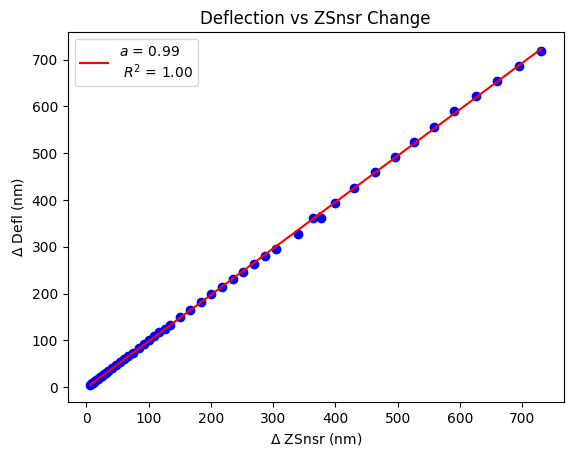

In [158]:

x = df_results['delta_z'] * 1e9
y = df_results['delta_defl'] * 1e9

slope, intercept, r, p, se = linregress(x, y)

fig, ax = plt.subplots()
ax.scatter(x, y, color = 'blue')
ax.plot(x, slope * x + intercept, color='red',
        label=f'$a$ = {slope:.2f} \n $R^2$ = {r**2:.2f}')
ax.legend()

ax.set_xlabel(r'$\Delta$ ZSnsr (nm)')
ax.set_ylabel(r'$\Delta$ Defl (nm)')
ax.set_title('Deflection vs ZSnsr Change')
plt.show()

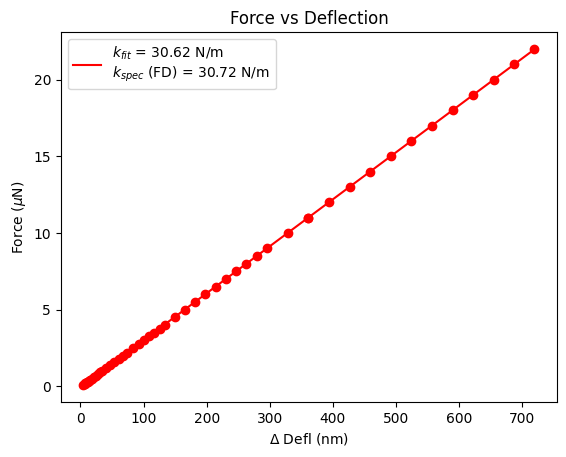

Spring constant k = 30.62 N/m


In [155]:
k_spec_FD  = 30.72 

x = df_results['delta_defl'] * 1e9
y = df_results['force'] * 1e6

slope, intercept, r, p, se = linregress(x, y)
k = slope * 1e-6 / 1e-9

fig, ax = plt.subplots()
ax.scatter(x, y, color = 'red')
ax.plot(x, slope * x + intercept, color='red',
        label=f'$k_{{fit}}$ = {k:.2f} N/m\n$k_{{spec}}$ (FD) = {k_spec_FD} N/m')
ax.set_ylabel(r'Force ($\mu$N)')
ax.set_xlabel(r'$\Delta$ Defl (nm)')
ax.set_title('Force vs Deflection')
ax.legend()
plt.show()

print(f'Spring constant k = {k:.2f} N/m')